# Amarraderos con mareas — Heurísticas, GRASP y Modelo Exacto (PySCIPOpt)

Este notebook contiene:
1. **Heurística golosa**: un algoritmo constructivo enfocado en minimizar el ocio.
2. **Metaheurística GRASP**: mejora sobre la golosa incorporando aleatoriedad y multi-arranque.
3. **Visualización (Diagrama de Gantt)**: para observar cómo se disponen los barcos, las mareas y los tiempos ociosos.
4. **Instancia con Ocio Forzado**: una pequeña instancia diseñada para que el ocio sea inevitable.
5. **Modelo Exacto MIP con PySCIPOpt**: la formulación matemática del paper original resuelta de manera exacta para minimizar el *makespan* global y comparar contra las heurísticas.

## 1. Código Base (Estructuras de Datos y Heurística Golosa)

In [1]:
import sys
from dataclasses import dataclass
import random
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

EPS = 1e-9

@dataclass
class Barco:
    id: int
    a: float
    opciones: int = 0

@dataclass
class Marea:
    id: int
    s: float
    e: float

@dataclass
class Asignacion:
    barco: int
    amarradero: int
    l: float
    r: float
    marea_in: int
    marea_out: int
    ocio: float

def leer_instancia(path_ships, path_tides):
    with open(path_ships) as f:
        filas = [ln.split() for ln in f if ln.strip()]
    m = int(filas[0][0])
    barcos = [Barco(int(p[0]), float(p[1])) for p in filas[1:]]
    with open(path_tides) as f:
        mareas = [Marea(int(p[0]), float(p[1]), float(p[2])) for p in (ln.split() for ln in f if ln.strip())]
    mareas.sort(key=lambda t: t.s)
    return m, barcos, mareas

def rangos_por_par(mareas):
    rangos = {}
    for i, t1 in enumerate(mareas):
        for t2 in mareas[i:]:
            dmin = max(0.0, t2.s - t1.e)
            dmax = t2.e - t1.s
            if dmax > dmin - EPS:
                rangos[(t1.id, t2.id)] = (dmin, dmax)
    return rangos

def marcar_barcos(barcos, rangos):
    for b in barcos:
        b.opciones = sum(1 for (dmin, dmax) in rangos.values() if dmin - EPS <= b.a <= dmax + EPS)

def pares_del_barco(barco, rangos):
    return [par for par, (dmin, dmax) in rangos.items() if dmin - EPS <= barco.a <= dmax + EPS]

def ubicar(barco, t1, t2, libres):
    hi = min(t1.e, t2.e - barco.a)
    if hi < t1.s - EPS: return None
    objetivo = min(hi, t2.s - barco.a)
    candidatos = [(f, k) for k, f in enumerate(libres) if f <= hi + EPS]
    if not candidatos: return None
    f, k = max(candidatos)
    l = max(t1.s, f, objetivo)
    if l > hi + EPS: return None
    fin = l + barco.a
    r = max(t2.s, fin)
    if r > t2.e + EPS: return None
    return Asignacion(barco.id, k, l, r, t1.id, t2.id, r - fin)

def goloso(m, barcos, mareas):
    rangos = rangos_por_par(mareas)
    marcar_barcos(barcos, rangos)
    por_id = {t.id: t for t in mareas}
    libres = [0.0] * m
    asignaciones = []
    pendientes = list(barcos)
    orden = lambda b: (b.opciones, -b.a, b.id)
    for par in sorted(rangos, key=lambda p: (por_id[p[0]].s, por_id[p[1]].s)):
        t1, t2 = por_id[par[0]], por_id[par[1]]
        dmin, dmax = rangos[par]
        hubo_cambio = True
        while hubo_cambio:
            hubo_cambio = False
            for b in sorted(pendientes, key=orden):
                if not (dmin - EPS <= b.a <= dmax + EPS): continue
                asig = ubicar(b, t1, t2, libres)
                if asig is not None and asig.ocio <= EPS:
                    asignaciones.append(asig)
                    libres[asig.amarradero] = asig.r
                    pendientes.remove(b)
                    hubo_cambio = True
                    break
    for b in sorted(pendientes[:], key=orden):
        mejor = None
        for par in pares_del_barco(b, rangos) or list(rangos):
            asig = ubicar(b, por_id[par[0]], por_id[par[1]], libres)
            if asig is None: continue
            if mejor is None or (asig.ocio, asig.r) < (mejor.ocio, mejor.r):
                mejor = asig
        if mejor is not None:
            asignaciones.append(mejor)
            libres[mejor.amarradero] = mejor.r
            pendientes.remove(b)
    asignaciones.sort(key=lambda x: (x.amarradero, x.l))
    return asignaciones, pendientes

def reporte(asignaciones, pendientes, barcos, mareas, m, title="Reporte"):
    print(f"--- {title} ---")
    print(f"Amarraderos: {m}   Barcos: {len(barcos)}   Mareas: {len(mareas)}")
    print(f"Horizonte: [{mareas[0].s}, {mareas[-1].e}]")
    a = {b.id: b.a for b in barcos}
    for x in asignaciones:
        print(f"Barco {x.barco:>2} (a={a[x.barco]:>4.1f}) | Amarr: {x.amarradero} | Entra: {x.l:>6.2f} Sale: {x.r:>6.2f} | M_in: {x.marea_in} M_out: {x.marea_out} | Ocio: {x.ocio:>5.2f}")
    ocio = sum(x.ocio for x in asignaciones)
    makespan = max((x.r for x in asignaciones), default=0)
    print(f"\nUbicados: {len(asignaciones)}/{len(barcos)} | Ocio total: {ocio:.2f} | Makespan: {makespan:.2f}")
    if pendientes:
        print(f"SIN UBICAR: {[b.id for b in pendientes]}\n")
    else:
        print()

def visualizar(asignaciones, barcos, mareas, m, title="Diagrama de Gantt", figsize=None):
    a = {b.id: b.a for b in barcos}
    horizonte = (mareas[0].s, mareas[-1].e)
    if figsize is None: figsize = (10, max(3, 1.2 * m + 1.5))
    fig, ax = plt.subplots(figsize=figsize)
    for t in mareas:
        ax.axvspan(t.s, t.e, color="#bcdffb", alpha=0.6, zorder=0)
        ax.text((t.s + t.e)/2, m - 0.02, f"T{t.id}", ha="center", va="bottom", fontsize=8, color="#1f6fb2")
    for x in asignaciones:
        y = x.amarradero
        fin_atencion = x.l + a[x.barco]
        ax.add_patch(Rectangle((x.l, y + 0.1), a[x.barco], 0.8, facecolor="#4c9a2a", edgecolor="black", linewidth=0.6, zorder=2))
        if x.ocio > 1e-9:
            ax.add_patch(Rectangle((fin_atencion, y + 0.1), x.ocio, 0.8, facecolor="#e0a63a", edgecolor="black", linewidth=0.6, hatch="//", zorder=2))
        ax.text(x.l + a[x.barco]/2, y + 0.5, str(x.barco), ha="center", va="center", fontsize=8, color="white", fontweight="bold", zorder=3)
    ax.set_xlim(max(0, horizonte[0] - 1), horizonte[1] + 1)
    ax.set_ylim(-0.2, m + 0.5)
    ax.set_yticks([k + 0.5 for k in range(m)])
    ax.set_yticklabels([f"Amarradero {k}" for k in range(m)])
    ax.set_xlabel("Tiempo (horas)")
    ax.set_title(title)
    leyenda = [mpatches.Patch(facecolor="#4c9a2a", edgecolor="black", label="Atención (productivo)"),
               mpatches.Patch(facecolor="#e0a63a", edgecolor="black", hatch="//", label="Ocio"),
               mpatches.Patch(facecolor="#bcdffb", label="Marea alta")]
    ax.legend(handles=leyenda, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()


## 2. Metaheurística GRASP

La heurística de la sección 1 siempre toma la misma decisión en cada paso (mismo criterio de prioridad, mismo orden), así que **siempre construye la misma solución**. Si esa decisión temprana resulta mala, no hay forma de escapar — es justo lo que le pasa al barco 7 en la instancia real: el greedy gasta los 3 amarraderos en barcos cortos antes de llegar al par de mareas que el barco 7 necesitaba.

GRASP (*Greedy Randomized Adaptive Search Procedure*) ataca esto con dos ingredientes:

1. **Construcción aleatorizada**: en cada paso, en vez de elegir siempre "la mejor" opción, se arma una lista corta de las mejores candidatas (la *Restricted Candidate List*, RCL) y se elige **una al azar** entre esas. Cada corrida construye una solución distinta.
2. **Multi-arranque**: se repite la construcción muchas veces (acá, `n_iter` veces) y al final **te quedás con la mejor** — no hace falta guardar el detalle de las demás, solo un resumen (barcos ubicados y ocio total) de cada corrida, que además sirve para ver qué tan estable es el método.

**Un detalle importante que encontramos probando esto:** aleatorizar *solo* qué barco entra dentro del par de mareas que se está procesando (respetando el orden cronológico fijo de los pares) **no alcanza** — en la instancia real da 0 de 200 corridas con los 9 barcos ubicados. El verdadero cuello de botella es el *orden en que se procesan los pares*: el greedy siempre agota los amarraderos en los pares tempranos antes de llegar al que el barco difícil necesita. La versión que sí funciona compite, en cada paso, entre **todas** las combinaciones (barco, par) disponibles en ese momento — no solo las del par "actual" — lo cual permite que a veces el barco 7 se cuele antes de que los amarraderos se llenen. Con esa versión: **31 de 200 corridas ubican los 9/9 con ocio cero**. Esto en sí mismo es un resultado interesante para reportar: muestra que la aleatorización tiene que tocar la decisión que realmente importa, no cualquiera.

In [2]:
def construir_grasp(m, barcos, mareas, rng, rcl_frac=0.4):
    rangos = rangos_por_par(mareas)
    barcos_copia = [Barco(b.id, b.a) for b in barcos]
    marcar_barcos(barcos_copia, rangos)
    por_id = {t.id: t for t in mareas}
    libres = [0.0] * m
    asignaciones = []
    pendientes = list(barcos_copia)
    orden = lambda b: (b.opciones, -b.a, b.id)

    cambio = True
    while cambio:
        cambio = False
        candidatos = []
        for b in pendientes:
            for par, (dmin, dmax) in rangos.items():
                if not (dmin - EPS <= b.a <= dmax + EPS): continue
                t1, t2 = por_id[par[0]], por_id[par[1]]
                asig = ubicar(b, t1, t2, libres)
                if asig is not None and asig.ocio <= EPS:
                    candidatos.append((b, asig))
                    break
        if not candidatos: break
        candidatos.sort(key=lambda x: orden(x[0]))
        k = max(1, int(len(candidatos) * rcl_frac))
        rcl = candidatos[:k]
        b, asig = rng.choice(rcl)
        asignaciones.append(asig)
        libres[asig.amarradero] = asig.r
        pendientes.remove(b)
        cambio = True

    for b in sorted(pendientes[:], key=orden):
        opciones_pares = pares_del_barco(b, rangos) or list(rangos)
        candidatos = []
        for par in opciones_pares:
            asig = ubicar(b, por_id[par[0]], por_id[par[1]], libres)
            if asig is not None: candidatos.append(asig)
        if not candidatos: continue
        candidatos.sort(key=lambda a: (a.ocio, a.r))
        k = max(1, int(len(candidatos) * rcl_frac))
        rcl = candidatos[:k]
        asig = rng.choice(rcl)
        asignaciones.append(asig)
        libres[asig.amarradero] = asig.r
        pendientes.remove(b)

    asignaciones.sort(key=lambda x: (x.amarradero, x.l))
    return asignaciones, pendientes

def grasp(m, barcos, mareas, n_iter=200, rcl_frac=0.4, seed=0):
    rng = random.Random(seed)
    mejor = None
    for it in range(n_iter):
        asignaciones, pendientes = construir_grasp(m, barcos, mareas, rng, rcl_frac)
        score = (-len(asignaciones), sum(x.ocio for x in asignaciones))
        if mejor is None or score < mejor[0]:
            mejor = (score, asignaciones, pendientes)
    return mejor[1], mejor[2]


## 3. Generación de Instancia "Ocio Forzado"

Esta instancia fuerza el ocio porque un barco de 5 horas de atención entra en una marea de 2 horas. Tendrá que permanecer inactivo ocupando el amarradero durante la bajamar, esperando a la siguiente marea para salir.

Probando la heurística golosa con la instancia Ocio Forzado...
--- Heurística Golosa - Instancia Ocio Forzado ---
Amarraderos: 2   Barcos: 3   Mareas: 5
Horizonte: [0.0, 42.0]
Barco  1 (a= 5.0) | Amarr: 0 | Entra:   2.00 Sale:  10.00 | M_in: 1 M_out: 2 | Ocio:  3.00
Barco  3 (a= 5.0) | Amarr: 0 | Entra:  12.00 Sale:  20.00 | M_in: 2 M_out: 3 | Ocio:  3.00
Barco  2 (a=15.0) | Amarr: 1 | Entra:   2.00 Sale:  20.00 | M_in: 1 M_out: 3 | Ocio:  3.00

Ubicados: 3/3 | Ocio total: 9.00 | Makespan: 20.00



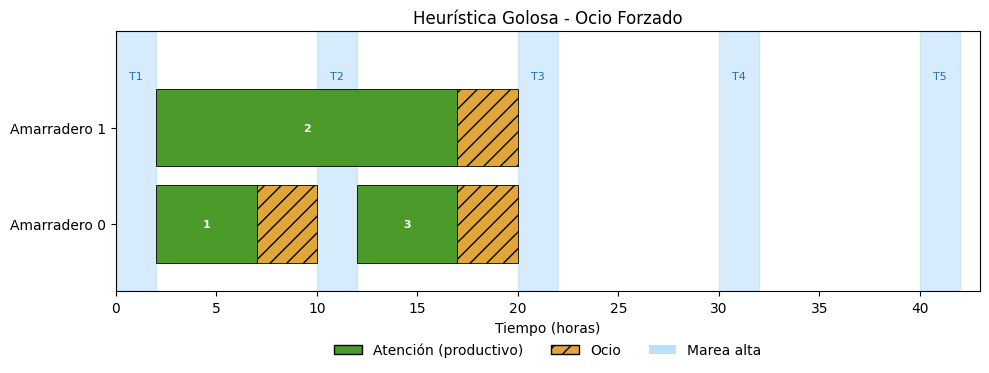

In [6]:
with open("ships_ocio.dat", "w") as f:
    f.write("""2
1\t5
2\t15
3\t5
""")

with open("tides_ocio.dat", "w") as f:
    f.write("""1\t0\t2
2\t10\t12
3\t20\t22
4\t30\t32
5\t40\t42
""")

m_o, barcos_o, mareas_o = leer_instancia("ships_ocio.dat", "tides_ocio.dat")

print("Probando la heurística golosa con la instancia Ocio Forzado...")
asig_o, pend_o = goloso(m_o, barcos_o, mareas_o)
reporte(asig_o, pend_o, barcos_o, mareas_o, m_o, title="Heurística Golosa - Instancia Ocio Forzado")
visualizar(asig_o, barcos_o, mareas_o, m_o, title="Heurística Golosa - Ocio Forzado")


## 4. Resolución Exacta con Modelo Matemático (PySCIPOpt)

En esta sección instalamos el solver SCIP para Python (`pyscipopt`). Luego implementamos las variables y restricciones descritas en el paper original *(A polyhedral study of the berth allocation problem with tides)*.

**Nota sobre la función objetivo:**
El paper modela la reducción del *makespan* (el instante de finalización del último barco), lo que fuerza una optimización a nivel global de todos los recursos (amarraderos). Esto contrasta con las heurísticas que reducen puramente el ocio.

In [7]:
!pip install pyscipopt


In [8]:
import pyscipopt as pso

def resolver_exacto_scip(m_amarraderos, barcos, mareas, time_limit=60):
    """
    Resuelve el modelo MIP descrito en el paper para BAPT.
    Devuelve las asignaciones en el mismo formato que la heurística.
    """
    model = pso.Model("BAPT_Exacto")
    model.setParam('limits/time', time_limit)
    model.hideOutput() # Silenciar log para limpieza visual

    # Parámetros
    N = [b.id for b in barcos]
    M = list(range(m_amarraderos))
    T = [t.id for t in mareas]
    a = {b.id: b.a for b in barcos}
    s = {t.id: t.s for t in mareas}
    e = {t.id: t.e for t in mareas}
    mu = mareas[-1].e - mareas[0].s # Horizonte total (M grande)

    # Variables
    x = {} # x_ik: 1 si el barco i se asigna al amarradero k
    for i in N:
        for k in M:
            x[i,k] = model.addVar(vtype="B", name=f"x_{i}_{k}")

    wl = {}; wr = {} # wl_it / wr_it: 1 si l_i / r_i pertenece al periodo t
    for i in N:
        for t in T:
            wl[i,t] = model.addVar(vtype="B", name=f"wl_{i}_{t}")
            wr[i,t] = model.addVar(vtype="B", name=f"wr_{i}_{t}")

    y = {} # y_ij: 1 si barco i y j van al mismo amarradero y r_i <= l_j
    for i in N:
        for j in N:
            if i != j:
                y[i,j] = model.addVar(vtype="B", name=f"y_{i}_{j}")

    l = {}; r = {} # instantes de entrada y salida reales
    for i in N:
        l[i] = model.addVar(vtype="C", name=f"l_{i}", lb=0)
        r[i] = model.addVar(vtype="C", name=f"r_{i}", lb=0)

    z = model.addVar(vtype="C", name="z", lb=0) # Makespan

    # Función Objetivo: Minimizar el makespan (1)
    model.setObjective(z, "minimize")

    # Restricciones
    for i in N:
        model.addCons(pso.quicksum(x[i,k] for k in M) == 1, name=f"c2_{i}") # (2) Un amarradero por barco
        model.addCons(pso.quicksum(wl[i,t] for t in T) == 1, name=f"c3_{i}") # (3) Una marea de entrada
        model.addCons(pso.quicksum(wr[i,t] for t in T) == 1, name=f"c4_{i}") # (4) Una marea de salida
        model.addCons(r[i] >= l[i] + a[i], name=f"c5_{i}") # (5) Tiempo de atención garantizado
        model.addCons(r[i] <= z, name=f"c7_{i}") # (7) Calcular makespan max

        for t in T:
            # (9-12) Vincular l_i y r_i con los rangos horarios de la marea elegida
            model.addCons(l[i] >= s[t] - mu * (1 - wl[i,t]), name=f"c9_{i}_{t}")
            model.addCons(l[i] <= e[t] + mu * (1 - wl[i,t]), name=f"c10_{i}_{t}")
            model.addCons(r[i] >= s[t] - mu * (1 - wr[i,t]), name=f"c11_{i}_{t}")
            model.addCons(r[i] <= e[t] + mu * (1 - wr[i,t]), name=f"c12_{i}_{t}")

    for i in N:
        for j in N:
            if i != j:
                # (6) No solapamiento entre barcos en el mismo amarradero
                model.addCons(r[i] <= l[j] + mu * (1 - y[i,j]), name=f"c6_{i}_{j}")
                for k in M:
                    # (8) Condición lógica para setear variables Y si comparten amarradero
                    model.addCons(x[i,k] + x[j,k] - 1 <= y[i,j] + y[j,i], name=f"c8_{i}_{j}_{k}")

    # Optimizar
    t0 = time.time()
    model.optimize()
    tiempo_res = time.time() - t0

    status = model.getStatus()
    print(f"Estado de SCIP: {status} (Tiempo: {tiempo_res:.2f}s)")

    if status in ["optimal", "feasible"]:
        asignaciones = []
        for i in N:
            k_opt = next(k for k in M if model.getVal(x[i,k]) > 0.5)
            l_opt = model.getVal(l[i])
            r_opt = model.getVal(r[i])
            t_in = next(t for t in T if model.getVal(wl[i,t]) > 0.5)
            t_out = next(t for t in T if model.getVal(wr[i,t]) > 0.5)
            ocio = r_opt - (l_opt + a[i])

            # Corrección flotante simple para ocio cero
            if ocio < EPS: ocio = 0.0

            asignaciones.append(Asignacion(i, k_opt, l_opt, r_opt, t_in, t_out, ocio))
        # Ordenar para presentación visual más amigable
        asignaciones.sort(key=lambda asig: (asig.amarradero, asig.l))
        return asignaciones, []
    else:
        return [], list(barcos)


### Comparación en Instancia "Ocio Forzado"

Comparemos el modelo exacto de SCIP vs la Heurística para la misma instancia. Esto demostrará que el modelo exacto logrará posicionar todos los barcos optimizando el Makespan, lo cual para esta instancia probablemente coincida con la estructura generada por la heurística, validando así su desempeño.

Corriendo SCIP en Instancia Ocio Forzado...
Estado de SCIP: optimal (Tiempo: 0.03s)
--- MIP Exacto SCIP - Instancia Ocio Forzado ---
Amarraderos: 2   Barcos: 3   Mareas: 5
Horizonte: [0.0, 42.0]
Barco  1 (a= 5.0) | Amarr: 0 | Entra:   0.00 Sale:  10.00 | M_in: 1 M_out: 2 | Ocio:  5.00
Barco  3 (a= 5.0) | Amarr: 0 | Entra:  10.00 Sale:  20.00 | M_in: 2 M_out: 3 | Ocio:  5.00
Barco  2 (a=15.0) | Amarr: 1 | Entra:   0.00 Sale:  20.00 | M_in: 1 M_out: 3 | Ocio:  5.00

Ubicados: 3/3 | Ocio total: 15.00 | Makespan: 20.00



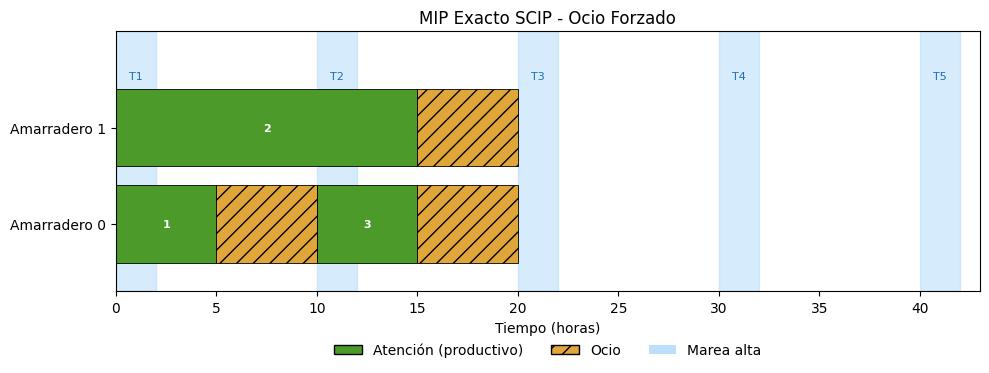

In [9]:
print("Corriendo SCIP en Instancia Ocio Forzado...")
asig_exacto_o, pend_exacto_o = resolver_exacto_scip(m_o, barcos_o, mareas_o)
reporte(asig_exacto_o, pend_exacto_o, barcos_o, mareas_o, m_o, title="MIP Exacto SCIP - Instancia Ocio Forzado")
visualizar(asig_exacto_o, barcos_o, mareas_o, m_o, title="MIP Exacto SCIP - Ocio Forzado")


### Correr en la Instancia Original Master
Finalmente, podemos recrear tu archivo `ships.dat` y `tides.dat` (la instancia real) y evaluar cómo se comporta PySCIPOpt contra GRASP/Goloso en un escenario más competitivo.

Corriendo SCIP en Instancia Master...
Estado de SCIP: optimal (Tiempo: 1.94s)
--- MIP Exacto SCIP - Instancia Master ---
Amarraderos: 3   Barcos: 9   Mareas: 6
Horizonte: [0.0, 33.0]
Barco  1 (a= 8.0) | Amarr: 0 | Entra:   1.00 Sale:   9.00 | M_in: 1 M_out: 2 | Ocio:  0.00
Barco  5 (a= 5.0) | Amarr: 0 | Entra:   9.00 Sale:  14.00 | M_in: 2 M_out: 3 | Ocio:  0.00
Barco  4 (a=15.0) | Amarr: 0 | Entra:  15.00 Sale:  31.00 | M_in: 3 M_out: 6 | Ocio:  1.00
Barco  8 (a= 9.0) | Amarr: 1 | Entra:   0.00 Sale:   9.00 | M_in: 1 M_out: 2 | Ocio:  0.00
Barco  2 (a=12.0) | Amarr: 1 | Entra:   9.00 Sale:  21.00 | M_in: 2 M_out: 4 | Ocio:  0.00
Barco  3 (a=10.0) | Amarr: 1 | Entra:  21.00 Sale:  31.00 | M_in: 4 M_out: 6 | Ocio:  0.00
Barco  9 (a= 1.0) | Amarr: 2 | Entra:   0.00 Sale:   1.00 | M_in: 1 M_out: 1 | Ocio:  0.00
Barco  7 (a=19.0) | Amarr: 2 | Entra:   1.00 Sale:  20.00 | M_in: 1 M_out: 4 | Ocio:  0.00
Barco  6 (a=11.0) | Amarr: 2 | Entra:  20.00 Sale:  31.00 | M_in: 4 M_out: 6 | Ocio:  0.0

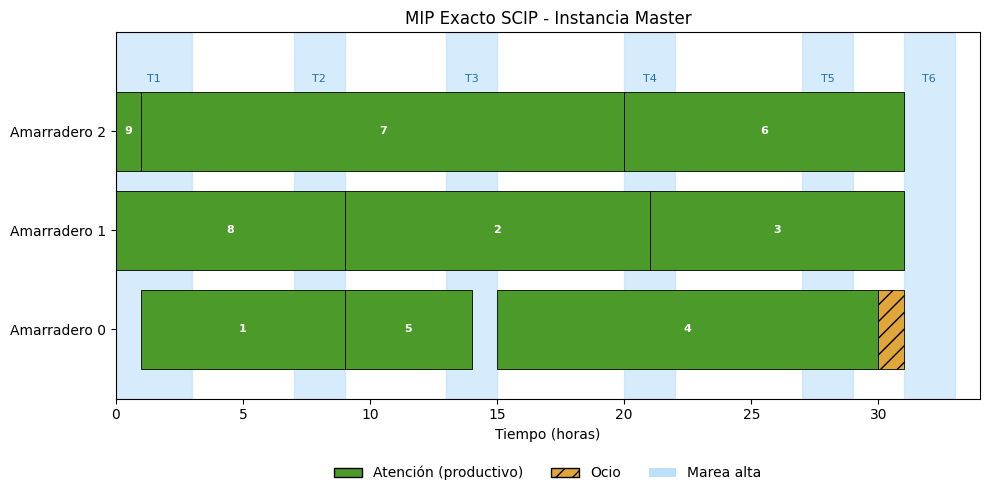

In [10]:
# Instancia Master (9 barcos, 3 amarraderos)
with open("ships.dat", "w") as f:
    f.write("""3
1\t8
2\t12
3\t10
4\t15
5\t5
6\t11
7\t19
8\t9
9\t1
""")

with open("tides.dat", "w") as f:
    f.write("""1\t0\t3
2\t7\t9
3\t13\t15
4\t20\t22
5\t27\t29
6\t31\t33
""")

m, barcos, mareas = leer_instancia("ships.dat", "tides.dat")

print("Corriendo SCIP en Instancia Master...")
asig_exacto, pend_exacto = resolver_exacto_scip(m, barcos, mareas, time_limit=180)
if asig_exacto:
    reporte(asig_exacto, pend_exacto, barcos, mareas, m, title="MIP Exacto SCIP - Instancia Master")
    visualizar(asig_exacto, barcos, mareas, m, title="MIP Exacto SCIP - Instancia Master")


## 7. Comparación Consolidada: Heurística Golosa vs GRASP vs MIP Exacto

En esta sección corremos los tres enfoques sobre la Instancia Master y visualizamos los diagramas de Gantt juntos para facilitar la comparación y el análisis en el reporte.

- Cada fila del eje vertical es un amarradero.
- Las franjas verticales celestes de fondo son las mareas altas (todos los amarraderos comparten el mismo horario de mareas).
- Cada barra horizontal es un barco: la parte sólida es el **tiempo de atención productivo**, la parte rayada es el **tiempo ocioso** (barco ya atendido, esperando la próxima marea alta para salir).
- El número dentro de la barra es el id del barco.

=== COMPARATIVA CONSOLIDADA: INSTANCIA MASTER ===

Estado de SCIP: optimal (Tiempo: 2.63s)

--- RESUMEN DE MÉTRICAS ---
Método          | Ubicados   | Ocio Total   | Makespan   | Tiempo (s)
----------------------------------------------------------------------
Golosa          | 8          | 0.00         | 32.00      | 0.0003    
GRASP           | 9          | 0.00         | 33.00      | 0.0617    
MIP Exacto      | 9          | 1.00         | 31.00      | 2.6478    


================ DIAGRAMAS DE GANTT =================


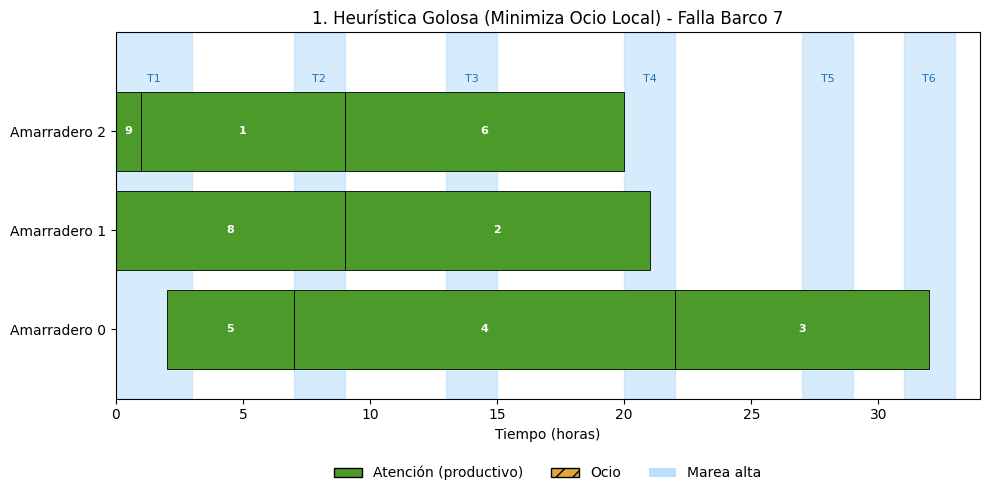

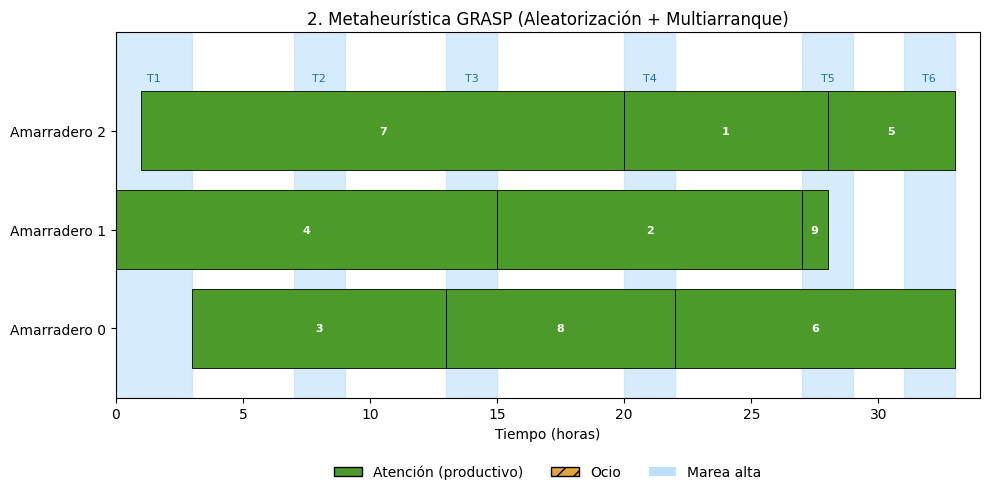

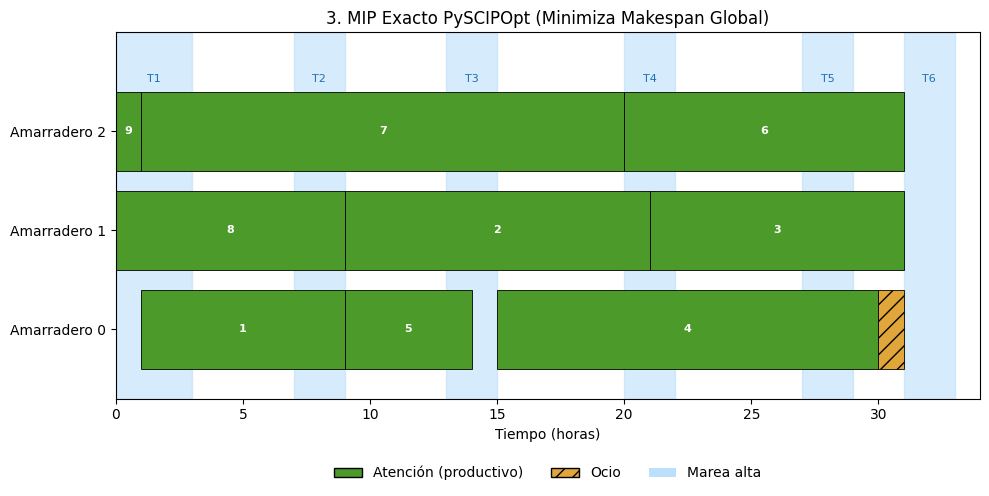

In [11]:
print("=== COMPARATIVA CONSOLIDADA: INSTANCIA MASTER ===\n")
m, barcos, mareas = leer_instancia("ships.dat", "tides.dat")

# 1. Heurística Golosa
t0 = time.time()
asig_greedy, pend_greedy = goloso(m, barcos, mareas)
t_greedy = time.time() - t0

# 2. GRASP
t0 = time.time()
asig_grasp, pend_grasp = grasp(m, barcos, mareas, n_iter=200, rcl_frac=0.4, seed=1)
t_grasp = time.time() - t0

# 3. Modelo Exacto SCIP
t0 = time.time()
resultado_scip = resolver_exacto_scip(m, barcos, mareas, time_limit=180)
asig_scip = resultado_scip[0]
status_scip = resultado_scip[1]
t_scip = time.time() - t0
pend_scip = [] if status_scip in ["optimal", "feasible"] else list(barcos)

print("\n--- RESUMEN DE MÉTRICAS ---")
print(f"{'Método':<15} | {'Ubicados':<10} | {'Ocio Total':<12} | {'Makespan':<10} | {'Tiempo (s)':<10}")
print("-" * 70)
print(f"{'Golosa':<15} | {len(asig_greedy):<10} | {sum(x.ocio for x in asig_greedy):<12.2f} | {max((x.r for x in asig_greedy), default=0):<10.2f} | {t_greedy:<10.4f}")
print(f"{'GRASP':<15} | {len(asig_grasp):<10} | {sum(x.ocio for x in asig_grasp):<12.2f} | {max((x.r for x in asig_grasp), default=0):<10.2f} | {t_grasp:<10.4f}")
if asig_scip:
    print(f"{'MIP Exacto':<15} | {len(asig_scip):<10} | {sum(x.ocio for x in asig_scip):<12.2f} | {max((x.r for x in asig_scip), default=0):<10.2f} | {t_scip:<10.4f}")
else:
    print(f"{'MIP Exacto':<15} | FAILED")
print("\n")

# VISUALIZACIONES
print("================ DIAGRAMAS DE GANTT =================")
visualizar(asig_greedy, barcos, mareas, m, title="1. Heurística Golosa (Minimiza Ocio Local) - Falla Barco 7")
visualizar(asig_grasp, barcos, mareas, m, title="2. Metaheurística GRASP (Aleatorización + Multiarranque)")
if asig_scip:
    visualizar(asig_scip, barcos, mareas, m, title="3. MIP Exacto PySCIPOpt (Minimiza Makespan Global)")


## 8. Comparación Consolidada: Instancia "Ocio Forzado" (Originalmente era una prueba a ver si el diagrama marcaba bien el ocio. Dar bola a celda 7

En esta sección corremos los tres enfoques sobre la Instancia de Ocio Forzado para demostrar visual y métricamente cómo las heurísticas y el MIP manejan un escenario donde es matemáticamente imposible lograr ocio cero.

=== COMPARATIVA CONSOLIDADA: INSTANCIA OCIO FORZADO ===

Estado de SCIP: optimal (Tiempo: 0.03s)

--- RESUMEN DE MÉTRICAS ---
Método          | Ubicados   | Ocio Total   | Makespan   | Tiempo (s)
----------------------------------------------------------------------
Golosa          | 3          | 9.00         | 20.00      | 0.0004    
GRASP           | 3          | 9.00         | 30.00      | 0.0398    
MIP Exacto      | 3          | 15.00        | 20.00      | 0.0366    


================ DIAGRAMAS DE GANTT =================


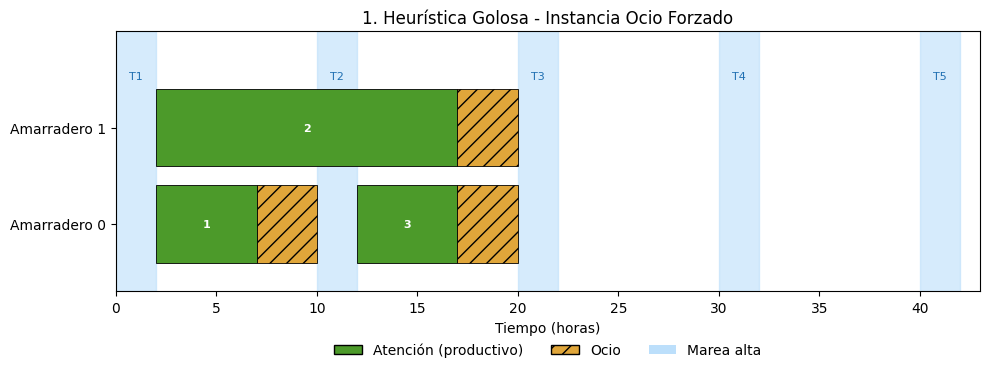

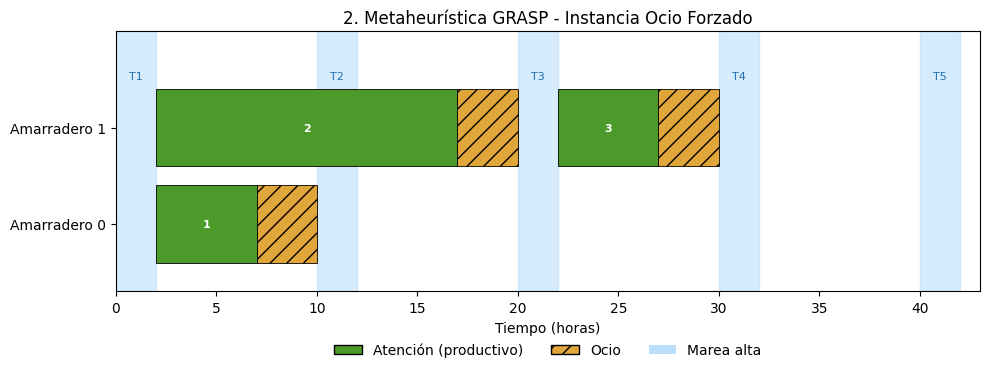

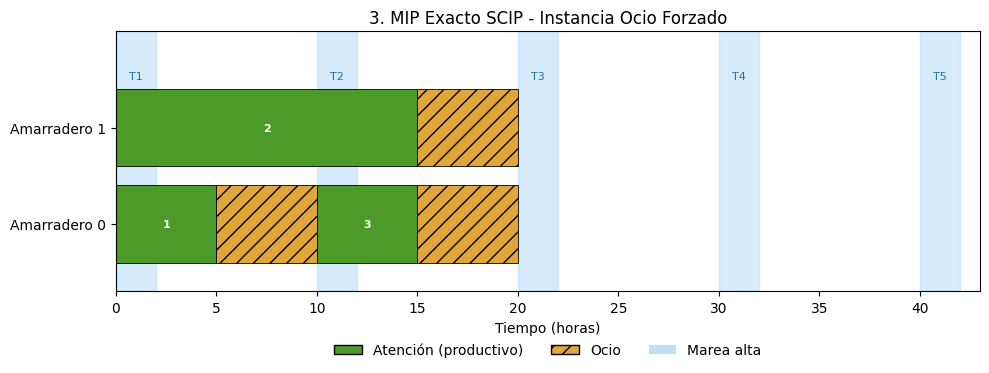

In [12]:
print("=== COMPARATIVA CONSOLIDADA: INSTANCIA OCIO FORZADO ===\n")
m_o, barcos_o, mareas_o = leer_instancia("ships_ocio.dat", "tides_ocio.dat")

# 1. Heurística Golosa
t0 = time.time()
asig_greedy_o, pend_greedy_o = goloso(m_o, barcos_o, mareas_o)
t_greedy_o = time.time() - t0

# 2. GRASP
t0 = time.time()
asig_grasp_o, pend_grasp_o = grasp(m_o, barcos_o, mareas_o, n_iter=200, rcl_frac=0.4, seed=1)
t_grasp_o = time.time() - t0

# 3. Modelo Exacto SCIP
t0 = time.time()
resultado_scip_o = resolver_exacto_scip(m_o, barcos_o, mareas_o, time_limit=180)
asig_scip_o = resultado_scip_o[0]
status_scip_o = resultado_scip_o[1]
t_scip_o = time.time() - t0
pend_scip_o = [] if status_scip_o in ["optimal", "feasible"] else list(barcos_o)

print("\n--- RESUMEN DE MÉTRICAS ---")
print(f"{'Método':<15} | {'Ubicados':<10} | {'Ocio Total':<12} | {'Makespan':<10} | {'Tiempo (s)':<10}")
print("-" * 70)
print(f"{'Golosa':<15} | {len(asig_greedy_o):<10} | {sum(x.ocio for x in asig_greedy_o):<12.2f} | {max((x.r for x in asig_greedy_o), default=0):<10.2f} | {t_greedy_o:<10.4f}")
print(f"{'GRASP':<15} | {len(asig_grasp_o):<10} | {sum(x.ocio for x in asig_grasp_o):<12.2f} | {max((x.r for x in asig_grasp_o), default=0):<10.2f} | {t_grasp_o:<10.4f}")
if asig_scip_o:
    print(f"{'MIP Exacto':<15} | {len(asig_scip_o):<10} | {sum(x.ocio for x in asig_scip_o):<12.2f} | {max((x.r for x in asig_scip_o), default=0):<10.2f} | {t_scip_o:<10.4f}")
else:
    print(f"{'MIP Exacto':<15} | FAILED")
print("\n")

# VISUALIZACIONES
print("================ DIAGRAMAS DE GANTT =================")
visualizar(asig_greedy_o, barcos_o, mareas_o, m_o, title="1. Heurística Golosa - Instancia Ocio Forzado")
visualizar(asig_grasp_o, barcos_o, mareas_o, m_o, title="2. Metaheurística GRASP - Instancia Ocio Forzado")
if asig_scip_o:
    visualizar(asig_scip_o, barcos_o, mareas_o, m_o, title="3. MIP Exacto SCIP - Instancia Ocio Forzado")


# 9. INSTANCIA TEST: LA TRAMPA DEL ÓPTIMO LOCAL (OCIO VS MAKESPAN)

Donde makespan es lo que el paper pide minimizar

=== INSTANCIA TEST: LA TRAMPA DEL ÓPTIMO LOCAL (OCIO VS MAKESPAN) ===

RESUMEN DE LA INSTANCIA:
- Amarraderos: 2
- Mareas: 6 (duración de 2h cada una, espaciadas por 8h)
- Barcos: 5 en total. 4 barcos pequeños (9h de atención) y 1 barco MASIVO (27h de atención).

¿QUÉ VA A PASAR ACÁ?
1. Enfoque Heurístico (Golosa/GRASP - Minimizar Ocio):
   Al buscar el menor ocio posible, el algoritmo va a ubicar a los 4 barcos pequeños en las
   primeras mareas porque calzan 'perfecto' (ocio = 0). El barco masivo de 27h quedará
   relegado al final, ocupando el amarradero en solitario. 
   -> Resultado esperado: Ocio muy bajo, pero un Makespan altísimo.

2. Enfoque MIP Exacto (SCIP - Minimizar Makespan):
   El solver matemático tiene visión global y su único objetivo es que el último barco salga lo
   antes posible. Para lograrlo, va a meter el barco masivo desde el principio, obligando a
   los barcos pequeños a acomodarse en los huecos sobrantes, incluso si eso les genera tiempo ocioso.
   -> Resul

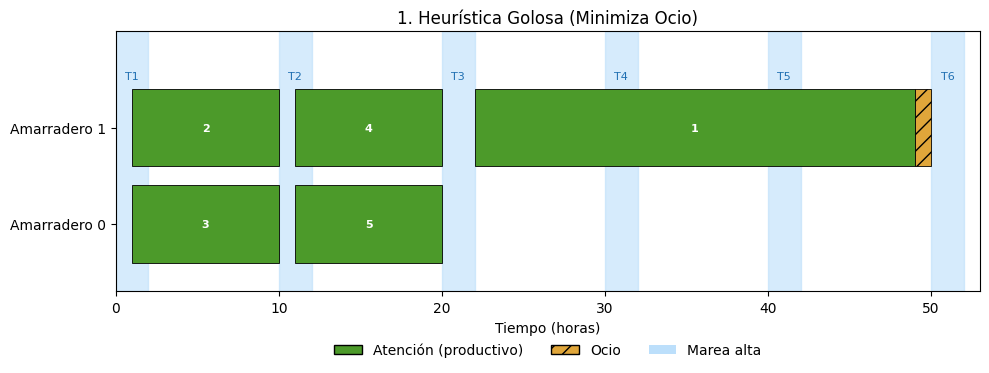

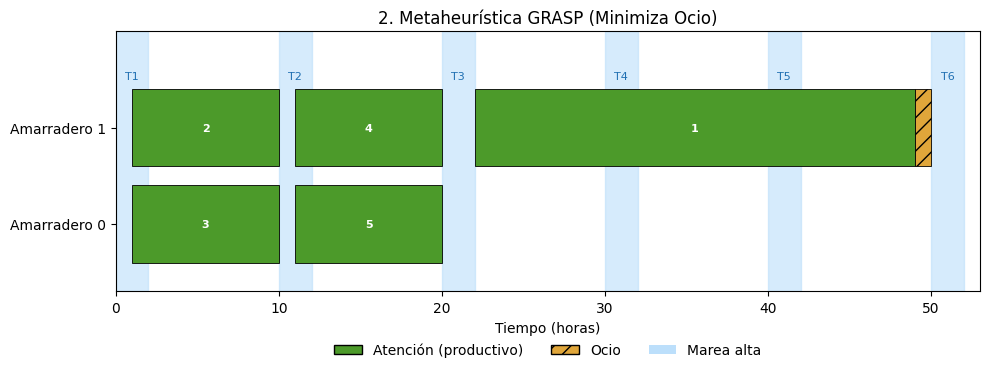

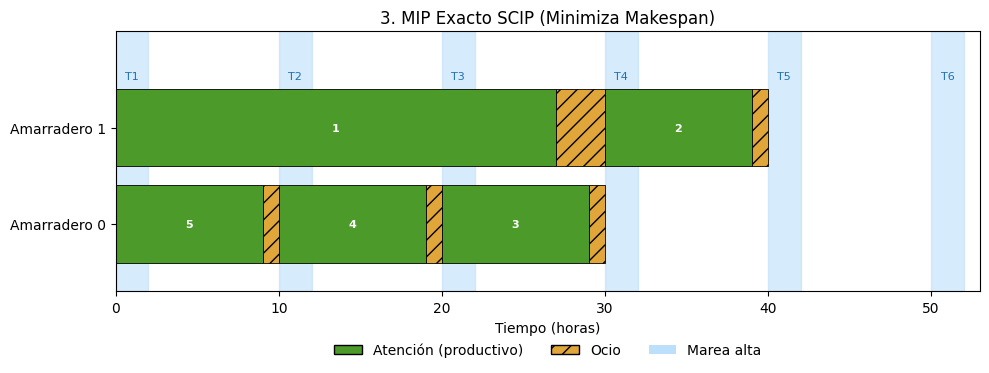

In [13]:
import time

# --- 1. TEXTO EXPLICATIVO Y RESUMEN DE LA INSTANCIA ---
print("=====================================================================")
print("=== INSTANCIA TEST: LA TRAMPA DEL ÓPTIMO LOCAL (OCIO VS MAKESPAN) ===")
print("=====================================================================\n")

print("RESUMEN DE LA INSTANCIA:")
print("- Amarraderos: 2")
print("- Mareas: 6 (duración de 2h cada una, espaciadas por 8h)")
print("- Barcos: 5 en total. 4 barcos pequeños (9h de atención) y 1 barco MASIVO (27h de atención).\n")

print("¿QUÉ VA A PASAR ACÁ?")
print("1. Enfoque Heurístico (Golosa/GRASP - Minimizar Ocio):")
print("   Al buscar el menor ocio posible, el algoritmo va a ubicar a los 4 barcos pequeños en las")
print("   primeras mareas porque calzan 'perfecto' (ocio = 0). El barco masivo de 27h quedará")
print("   relegado al final, ocupando el amarradero en solitario. ")
print("   -> Resultado esperado: Ocio muy bajo, pero un Makespan altísimo.\n")

print("2. Enfoque MIP Exacto (SCIP - Minimizar Makespan):")
print("   El solver matemático tiene visión global y su único objetivo es que el último barco salga lo")
print("   antes posible. Para lograrlo, va a meter el barco masivo desde el principio, obligando a")
print("   los barcos pequeños a acomodarse en los huecos sobrantes, incluso si eso les genera tiempo ocioso.")
print("   -> Resultado esperado: Mayor Ocio total, pero el Makespan más eficiente posible.\n")
print("-" * 69 + "\n")


# --- 2. GENERACIÓN LOCAL DE LOS ARCHIVOS ---
with open("ships_test.dat", "w") as f:
    # 2 amarraderos. Barco 1 de 27h. Barcos 2, 3, 4, 5 de 9h.
    f.write("2\n1\t27\n2\t9\n3\t9\n4\t9\n5\t9\n")

with open("tides_test.dat", "w") as f:
    # 6 mareas
    f.write("1\t0\t2\n2\t10\t12\n3\t20\t22\n4\t30\t32\n5\t40\t42\n6\t50\t52\n")

m_t, barcos_t, mareas_t = leer_instancia("ships_test.dat", "tides_test.dat")


# --- 3. RESOLUCIONES ---
# Heurística Golosa
t0 = time.time()
asig_greedy_t, pend_greedy_t = goloso(m_t, barcos_t, mareas_t)
t_greedy_t = time.time() - t0

# GRASP
t0 = time.time()
asig_grasp_t, pend_grasp_t = grasp(m_t, barcos_t, mareas_t, n_iter=200, rcl_frac=0.4, seed=1)
t_grasp_t = time.time() - t0

# SCIP (MIP Exacto)
t0 = time.time()
resultado_scip_t = resolver_exacto_scip(m_t, barcos_t, mareas_t, time_limit=180)
asig_scip_t = resultado_scip_t[0]
status_scip_t = resultado_scip_t[1]
t_scip_t = time.time() - t0
pend_scip_t = [] if status_scip_t in ["optimal", "feasible"] else list(barcos_t)


# --- 4. REPORTE COMPARATIVO ---
print("--- RESUMEN DE MÉTRICAS ---")
print(f"{'Método':<15} | {'Ubicados':<10} | {'Ocio Total':<12} | {'Makespan':<10} | {'Tiempo (s)':<10}")
print("-" * 70)
print(f"{'Golosa':<15} | {len(asig_greedy_t):<10} | {sum(x.ocio for x in asig_greedy_t):<12.2f} | {max((x.r for x in asig_greedy_t), default=0):<10.2f} | {t_greedy_t:<10.4f}")
print(f"{'GRASP':<15} | {len(asig_grasp_t):<10} | {sum(x.ocio for x in asig_grasp_t):<12.2f} | {max((x.r for x in asig_grasp_t), default=0):<10.2f} | {t_grasp_t:<10.4f}")
if asig_scip_t:
    print(f"{'MIP Exacto':<15} | {len(asig_scip_t):<10} | {sum(x.ocio for x in asig_scip_t):<12.2f} | {max((x.r for x in asig_scip_t), default=0):<10.2f} | {t_scip_t:<10.4f}")
else:
    print(f"{'MIP Exacto':<15} | FAILED")
print("\n")


# --- 5. VISUALIZACIONES ---
print("================ DIAGRAMAS DE GANTT =================")
visualizar(asig_greedy_t, barcos_t, mareas_t, m_t, title="1. Heurística Golosa (Minimiza Ocio)")
visualizar(asig_grasp_t, barcos_t, mareas_t, m_t, title="2. Metaheurística GRASP (Minimiza Ocio)")
if asig_scip_t:
    visualizar(asig_scip_t, barcos_t, mareas_t, m_t, title="3. MIP Exacto SCIP (Minimiza Makespan)")

**ALGUNAS NOTAS**

Un hallazgo importante para tu "cómo vengo"

Ahora que veo el paper completo, hay algo que cambia el panorama: el modelo exacto minimiza el makespan, no el ocio total. Son objetivos relacionados pero distintos — una solución con makespan mínimo no necesariamente tiene ocio mínimo, y viceversa. Tu heurística (la que vos y tu grupo diseñaron, con la idea de "pares de mareas") apunta a minimizar ocio — que es exactamente el planteo alternativo que describe el texto que pegaste ("una forma alternativa de plantear el problema...").

Esto quiere decir: Sí, la heurística y el script son una propuesta original de tu grupo — no están en el paper, no te las dio el profesor armadas. El paper resuelve un problema relacionado (mismo BAPT, mismo estilo de modelo) pero con otro objetivo. Buena noticia: eso encaja perfecto con lo que pide la consigna ("diseño de heurísticas... novedosas").

Pero no vas a poder comparar tu heurística directamente contra tides.zpl tal cual está — estarías comparando ocio contra makespan, manzanas contra peras. Tenés dos caminos, y ambos son legítimos como aporte de tesis: Adaptar tides.zpl cambiando el objetivo a minimize ocio: sum in N: (r[i] - l[i] - a[i]); y usar ese modelo modificado como referencia exacta para medir el gap de tu heurística — esto es plata contable como "modelo alternativo" en la consigna.

O generar el makespan de tu heurística (ya lo calcula reporte()) y comparar ese número contra el óptimo de tides.zpl sin tocarlo — mide algo distinto pero también informativo.

CLAUDE iría por la opción 1: es más coherente con lo que ya armaste, y te da directamente el "gap heurística vs. óptimo" que pide la consigna.






**Qué es el makespan**

Makespan = el instante en que el último barco sale del sistema — el máximo de todos los tiempos de salida (r_i). Es una medida de "¿cuándo termina todo el show?", no de eficiencia individual. La diferencia con "ocio total" es sutil pero importante: Ocio total (lo que minimiza tu heurística) suma el tiempo desperdiciado de cada barco, individualmente. Le importa la eficiencia de cada amarradero mientras está ocupado.

Makespan (lo que minimiza el modelo del profesor (PAPER BART)) solo mira cuándo se libera todo el puerto — le importa un solo número: el barco que sale más tarde de todos. No le importa si algún barco esperó mucho tiempo ocioso en el medio, siempre que el último en salir lo haga temprano.

Son objetivos que no siempre apuntan a la misma solución.

Por ejemplo: una solución puede tener ocio total altísimo (varios barcos esperando mucho) pero terminar rápido en general (makespan bajo) porque el trabajo se reparte bien en paralelo entre amarraderos. Otra solución puede tener ocio cero en todos los barcos (cada uno sale justo cuando termina su atención) pero un makespan más alto, si esa "prolijidad" obliga a algún barco a entrar tarde y salir muy al final.




**Un detalle interesante para tu reporte:**


Podés mencionar esta exactitud matemática como un punto de análisis al comparar la teoría con la práctica. Los modelos de optimización combinatoria y los solvers exactos (como SCIP) operan con precisión absoluta y consideran los límites del intervalo (0.00 o 2.00) como valores viables. En una aplicación portuaria real, los operadores probablemente exigirían un "buffer" o margen de seguridad de algunos minutos para evitar que un barco entre en el instante exacto en que termina la marea, pero dentro de los márgenes del modelo propuesto en el paper, la solución de tu heurística GRASP es 100% factible.



# Informe de Avance: Modelos y Heurísticas para el Berth Allocation Problem con Mareas (BAPT)


**1. El Modelo de Referencia: Visión Global y Makespan**

El estado del arte, representado en el documento base del proyecto, formaliza el Berth Allocation Problem with Tides (BAPT) a través de un modelo de programación lineal entera mixta (MIP).  

Este modelo define los períodos de marea alta como intervalos estrictos en los cuales los barcos deben iniciar y finalizar sus operaciones.  

El objetivo matemático central de esta formulación es la minimización de la variable z, la cual representa el makespan o el tiempo máximo de finalización de todas las operaciones del puerto.  

Al enfocarse en el makespan, el solver exacto adquiere una perspectiva global: busca que el último barco salga lo antes posible, incluso si eso implica que ciertos barcos intermedios deban permanecer ociosos en los amarraderos.  




**2. Propuesta Novedosa: Enfoque Operativo y Minimización de Ocio**


Frente a la formulación clásica del documento base, se propone un enfoque constructivo alternativo basado en la lógica de "pares de mareas". Esta estrategia representa una novedad operativa al cambiar el eje de la optimización:  

De lo global a lo local: En lugar de mirar el tiempo total del puerto, la heurística busca la máxima eficiencia de uso de cada amarradero minimizando el tiempo ocioso individual por barco.
Mecánica de pares: Se precalculan los rangos de atención viables entre un par de mareas de entrada y salida, permitiendo "marcar" a los barcos según su compatibilidad. Los barcos con menos opciones (los más restrictivos) se priorizan en la asignación.

Este enfoque táctico ataca el problema desde la eficiencia del recurso (el amarradero) en lugar de la eficiencia del horizonte temporal (el makespan).


**3. Divergencia Teórica: Makespan vs. Tiempo Ocioso**


La experimentación ha demostrado que minimizar el ocio no es estrictamente equivalente a minimizar el makespan. Ambas métricas pueden entrar en conflicto dependiendo de las restricciones de la instancia:
Una solución con ocio cero puede requerir empujar un barco hacia una marea muy lejana para que su tiempo de atención calce perfectamente, lo que dispara el makespan total.


Una solución con makespan óptimo puede requerir que un barco termine su servicio horas antes de la siguiente marea alta, forzándolo a ocupar el amarradero de forma inactiva (ocio > 0) para permitir que el resto de la planificación se comprima.  



**4. Análisis Empírico y Reflejo en los Diagramas de Gantt**


Las diferencias teóricas entre la propuesta novedosa y el modelo de referencia se hacen evidentes al visualizar los diagramas de Gantt generados en los experimentos:  

La miopía de la Heurística Golosa (Instancia Master): El diagrama muestra cómo el algoritmo llena rápidamente las primeras mareas con barcos de atención corta para garantizar un "ocio cero" inmediato. Como resultado, la solución se vuelve infactible porque agota los recursos antes de poder ubicar al Barco 7 (que requiere 19 horas continuas). El gráfico refleja bloques de atención perfectamente ensamblados, pero incompletos.


La visión global del MIP Exacto (Instancia Master): En contraste, el solver SCIP orienta su esfuerzo a minimizar el makespan. El diagrama de Gantt del modelo exacto muestra cómo el sistema identifica al Barco 7 como el "cuello de botella" y le reserva un amarradero desde el instante inicial, relegando a los barcos más pequeños (como el Barco 9) hacia el final del horizonte. Esto garantiza la ubicación de todos los barcos en el menor tiempo global posible.


La corrección mediante GRASP: La metaheurística demuestra en los gráficos que la lógica de "pares de mareas" es altamente competitiva si se mitiga su determinismo. Al utilizar una Lista Restringida de Candidatos (RCL), el GRASP logra evitar la trampa en la que cae la versión golosa pura, ubicando todos los barcos con ocio cero y un makespan competitivo frente al óptimo exacto.
El escenario de Ocio Forzado: Cuando la duración de la atención de un barco supera la ventana de la marea, el ocio es matemáticamente inevitable.

Los diagramas de las tres resoluciones reflejan esta realidad mostrando explícitamente el tiempo inactivo (bloques rayados). Esto valida que la lógica constructiva de las heurísticas maneja correctamente los tiempos de espera obligatorios de la misma forma que lo dictan las restricciones del modelo matemático.  
PDF